<a href="https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_2_2_Probability_Random_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_2_2_Probability_Random_Variables.ipynb)

# MAT 422 - Section 2.2: Probability and Random Variables

**Topics:** Probability axioms, Conditional probability, Discrete random variables, Continuous random variables


In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## Probability axioms

This section gives one compact Python demonstration of **Probability axioms**.


(Interpretation) The probability axioms:

1: All probabilities are nonnegative

2: The probability of the sample space is 1

3: Given a sequence of mutually exclusive events, the probability of their union is the sum of their individual probabilities.


In [36]:
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.ones(6) / 6
event_a = outcomes % 2 == 0
event_b = outcomes >= 5

print("Probabilities nonnegative:", np.all(probabilities >= 0))
print("Total probability:", probabilities.sum())
print("P(A: even) =", probabilities[event_a].sum())
print("P(B: at least 5) =", probabilities[event_b].sum())
print("P(A union B) =", probabilities[event_a | event_b].sum())
print("P(A) + P(B) - P(A and B) =", probabilities[event_a].sum() + probabilities[event_b].sum() - probabilities[event_a & event_b].sum())

# (NEW) P(A) and P(B\A) are mutually exclusive, but we can show the third axiom clearer
# C: at most 3
print()
print("(NEW)")
event_c = outcomes <= 3
print("P(B: at least 5) =", probabilities[event_b].sum())
print("P(C: at most 5) =", probabilities[event_c].sum())
print("Disjoint check: probability A and B =", probabilities[event_b & event_c].sum())
print("Probability of union of B and C =", probabilities[event_b | event_c].sum())
print("P(B) + P(C) =",  probabilities[event_b].sum()+ probabilities[event_c].sum())


Probabilities nonnegative: True
Total probability: 0.9999999999999999
P(A: even) = 0.5
P(B: at least 5) = 0.3333333333333333
P(A union B) = 0.6666666666666666
P(A) + P(B) - P(A and B) = 0.6666666666666666

(NEW)
P(B: at least 5) = 0.3333333333333333
P(C: at most 5) = 0.5
Disjoint check: probability A and B = 0.0
Probability of union of B and C = 0.8333333333333333
P(B) + P(C) = 0.8333333333333333


## Conditional probability

Conditional probability P(A|B) is the chance A happens on the condition B happens. It is defined as P(A and B)/P(B).


In [37]:
prevalence = 0.08
sensitivity = 0.92
false_positive = 0.07

p_positive = sensitivity * prevalence + false_positive * (1 - prevalence)
p_disease_given_positive = sensitivity * prevalence / p_positive

print("P(positive) =", round(p_positive, 4))
print("P(disease | positive) =", round(p_disease_given_positive, 4))


P(positive) = 0.138
P(disease | positive) = 0.5333


(NEW) The "p_disease_given_postive" line uses bayes rule: P(A|B)=P(B|A)*P(A)/P(B)

In this case, A is whether an individual has a disease, and B is the chance someone is positive.

(The calculation of p_positive uses total expectation)

We can reverse bayes' rule: P(B|A)=P(A|B)*P(B)/P(A) to calculate sensitivity below.

In [38]:
print("P(disease | positive)*P(positive)/P(disease) =", p_disease_given_positive * p_positive/prevalence)
print("P(positive | disease)", sensitivity)

P(disease | positive)*P(positive)/P(disease) = 0.9199999999999999
P(positive | disease) 0.92


## Discrete random variables

In descrete random variables, the sample space is fixed values (countable). The set [0, 1, 2, 3] is countable, but R (real numbers) is not.


E[X] = 1.8
Var(X) = 0.8600000000000001


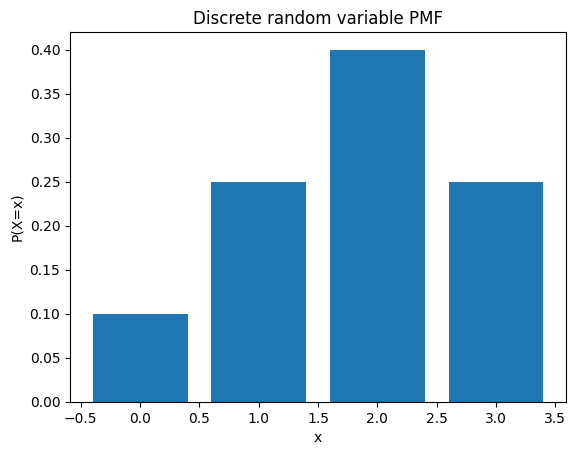

In [39]:
x = np.array([0, 1, 2, 3])
pmf = np.array([0.10, 0.25, 0.40, 0.25])
expected_value = np.sum(x * pmf)
variance = np.sum((x - expected_value) ** 2 * pmf)

print("E[X] =", expected_value)
print("Var(X) =", variance)

plt.bar(x, pmf, color="tab:blue")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("Discrete random variable PMF")
plt.show()


(NEW) The PMF given is [0.10, 0.25, 0.40, 0.25]. We can check whether it is a valid PMF by using the first two axioms of probability (no negative values, and sum to one).

In [40]:
print("pmf all nonnegative?", all(x >= 0 for x in pmf))
print("pmf sum =", pmf.sum())

pmf all nonnegative? True
pmf sum = 1.0


## Continuous random variables

For continuous random variables, the sample space is infinite. The PMF is defined slightly differently, and the integral between two points is the probability that the variable is between the two. However, it is still bound by the axioms of probability (no negative probability and total integral must be 1)

Approximate total area under PDF = 0.9983521280234394
Approximate P(X <= 2) = 0.7961629342219793


/tmp/ipykernel_1670/822439544.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  approx_area = np.trapz(pdf, grid)
/tmp/ipykernel_1670/822439544.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p_less_than_2 = np.trapz(pdf[grid <= 2], grid[grid <= 2])


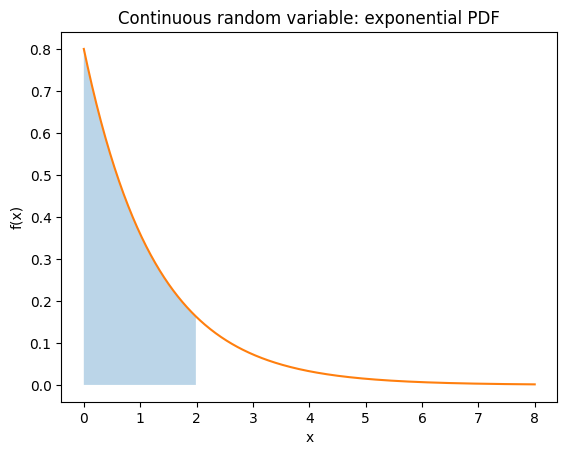

In [41]:
grid = np.linspace(0, 8, 500)
rate = 0.8
pdf = rate * np.exp(-rate * grid)
approx_area = np.trapz(pdf, grid)
p_less_than_2 = np.trapz(pdf[grid <= 2], grid[grid <= 2])

print("Approximate total area under PDF =", approx_area)
print("Approximate P(X <= 2) =", p_less_than_2)

plt.plot(grid, pdf, color="tab:orange")
plt.fill_between(grid[grid <= 2], pdf[grid <= 2], alpha=0.3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Continuous random variable: exponential PDF")
plt.show()


(NEW)

The approximate area is close to 1 which suggests that the total probability is one, but we can prove it:

Area = integral of (0.8*e^(-0.8t)dt) from -inf to inf

= [-e^(-0.8t)] from 0 to inf

= (-e^(-0.8*inf))-(-e^(-0.8\*0))

= (-e^(-inf))-(-e^(0))

= -0-(-1)

=1

## Reflection and Submission Checklist

- I explained each concept in words before or after the code.
- I verified important claims numerically or visually.
- I changed or extended at least one example so the notebook reflects my own work.
- I ran the notebook from top to bottom without errors.
- I saved the notebook from Google Colab directly to GitHub, following the course instructions.
